In [ ]:
import pickle
import optuna
import pretty_midi
import muspy
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from dataclasses import dataclass
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import scipy


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Pre processamento dos dados

In [ ]:
def trim_constant_frames(score):
    """
    faz o pre processamento do score, tirando o silencio no inicio e no fim de um score
    """
    is_constant = np.all(score == score[:, [0]], axis=1)
    if not np.any(~is_constant):
        return score

    first = np.argmax(~is_constant)
    last = len(is_constant) - np.argmax(~is_constant[::-1])

    return score[first:last]

def standardize_and_clean(score, num_channels=4, min_len=96):
    """
    garante que os dados estao todos no formato esperado do NES com 4 canais.
    O min_len representa o tempo minimo esperado de um score, como a frequencia
    do formato escolhido eh de 24 Hz, 96 frames seria equivalente a 4 segundos
    """
    assert isinstance(score, np.ndarray)
    assert score.ndim == 2
    assert score.shape[1] == num_channels

    score = score.astype(np.int64)

    score = trim_constant_frames(score)

    if score.shape[0] < min_len:
        return None

    return score

def segment_into_windows(score, window_size, stride):
    """
    fragmenta um score em varias janelas, que vao ser recebidas pelo modelo VAE
    window_size: controla o tamanho da janela que fragmentam a musica
    stride: tamanho da distancia entre janelas
    score: np.ndarray, shape (T, C)
    returns: np.ndarray, shape (N, W, C)
    """
    T = score.shape[0]
    W = window_size
    S = stride

    windows = []

    for i in range(0, T - W + 1, S):
        windows.append(score[i:i+W])

    return np.stack(windows)

def process_song(path, window_size, stride, min_len):
    """
    Processa um arquivo .seprsco.pkl
    Retorna np.ndarray (N, W, C) ou None
    """
    with open(path, "rb") as f:
        data = pickle.load(f)

    score = data[2] # a dado desse tipo tem 3 elementos, a array com o score em si eh o 3o

    score = standardize_and_clean(score, num_channels=4, min_len=min_len)
    if score is None:
        return None

    windows = segment_into_windows(score, window_size, stride)
    return windows

def process_split(split_dir, window_size=96, stride=24, min_len=96):
    """
    Processa uma pasta inteira (train, test ou valid)
    Retorna X_split com shape (N, W, C)
    """
    all_windows = []

    split_dir = Path(split_dir)
    files = sorted(split_dir.glob("*.seprsco.pkl"))

    for path in files:
        print(f"processando: {path}")
        windows = process_song(
            path,
            window_size=window_size,
            stride=stride,
            min_len=min_len
        )

        if windows is not None:
            all_windows.append(windows)

    if len(all_windows) == 0:
        return None

    return np.concatenate(all_windows, axis=0)


In [ ]:
W = 96
STRIDE = 24
MIN_LEN = 96

X_train = process_split("train", W, STRIDE, MIN_LEN)
X_test  = process_split("test",  W, STRIDE, MIN_LEN)
X_valid = process_split("valid", W, STRIDE, MIN_LEN)


In [ ]:
print(X_train.shape)
print(X_test.shape)
print(X_valid.shape)

In [ ]:
np.savez_compressed(
    "nes_dataset_windows.npz",
    X_train=X_train,
    X_test=X_test,
    X_valid=X_valid
)

In [ ]:
data = np.load("nes_dataset_windows.npz")
X_train = data["X_train"]
X_test  = data["X_test"]
X_valid = data["X_valid"]

# ===============================
# Subamostragem do treino (10%)
# ===============================
np.random.seed(42)  # reprodutibilidade

n_total = X_train.shape[0]
n_subset = int(0.1 * n_total)

indices = np.random.choice(n_total, size=n_subset, replace=False)
X_train = X_train[indices]

print(f"Usando {n_subset} de {n_total} janelas de treino ({100*n_subset/n_total:.1f}%)")

Usando 13004 de 130043 janelas de treino (10.0%)


### Conversao das janelas geradas em musica audivel

In [ ]:
def windows_to_score_overlap(windows, stride):
    """
    windows: np.ndarray (N, W, C)
    stride: int
    returns: np.ndarray (T, C)
    """
    N, W, C = windows.shape
    T = stride * (N - 1) + W

    score = np.zeros((T, C), dtype=np.float32)
    weight = np.zeros((T, 1), dtype=np.float32)

    t = 0
    for w in windows:
        score[t:t+W] += w
        weight[t:t+W] += 1
        t += stride

    score = score / np.maximum(weight, 1e-8)
    return np.round(score).astype(np.int64)

def remove_short_notes(score, min_duration=2):
    """
    score: np.ndarray (T, C)
    min_duration: numero minimo de frames
    """
    T, C = score.shape
    out = score.copy()

    for c in range(C):
        t = 0
        while t < T:
            pitch = out[t, c]

            if pitch == 0:
                t += 1
                continue

            t0 = t
            while t < T and out[t, c] == pitch:
                t += 1

            if t - t0 < min_duration:
                out[t0:t, c] = 0

    return out



def piano_roll_to_midi(score, fs=24):
    """
    score: np.ndarray (T, C)
    fs: frames per second
    returns: pretty_midi.PrettyMIDI
    """
    pm = pretty_midi.PrettyMIDI()
    instruments = []

    # cria 4 instrumentos genéricos
    for _ in range(score.shape[1]):
        instr = pretty_midi.Instrument(program=pretty_midi.instrument_name_to_program("Lead 1 (square)"))
        instruments.append(instr)
        pm.instruments.append(instr)

    T, C = score.shape

    for c in range(C):
        t = 0
        while t < T:
            pitch = score[t, c]

            if pitch == 0:
                t += 1
                continue

            start = t
            while t < T and score[t, c] == pitch:
                t += 1

            end = t

            note = pretty_midi.Note(
                velocity=100,
                pitch=int(pitch),
                start=start / fs,
                end=end / fs
            )
            instruments[c].notes.append(note)

    return pm

def normalize_to_range(arr):
    arr = np.asarray(arr, dtype=np.float32)
    min_val = arr.min()
    max_val = arr.max()

    if max_val == min_val:
        return np.zeros_like(arr)  # evita divisão por zero

    return (arr - min_val) * 127 / (max_val - min_val)


In [ ]:
# exemplo de uso da musica
normalizedGen = normalize_to_range(X_gen)
score = windows_to_score_overlap(X_gen, stride=24) # X_gen eh a musica gerada pelo modelo
score = remove_short_notes(score, min_duration=2)

pm = piano_roll_to_midi(score, fs=24)
pm.write("musicGen.mid")


## PPCA


### EM para o PPCA

In [ ]:
W_SIZE = 96
C = 4
D = W_SIZE * C

def E_step(Xc, W, sigma2):
    N, D = Xc.shape
    L = W.shape[1]

    M = W.T @ W + sigma2 * np.eye(L)
    L_chol = np.linalg.cholesky(M)
    M_inv = scipy.linalg.cho_solve((L_chol, True), np.eye(L))

    Ez = Xc @ W @ M_inv
    Ezz = sigma2 * M_inv

    return Ez, Ezz

def M_step(S_xz, S_zz, S_xx, N, D):
    W_new = S_xz @ np.linalg.inv(S_zz)

    sigma2_new = (
        S_xx
        - 2 * np.trace(W_new @ S_xz.T)
        + np.trace(W_new.T @ W_new @ S_zz)
    ) / (N * D)

    return W_new, sigma2_new

def EM_numpy(Xc, W, sigma2, max_iter=100, tol=1e-5):
    N, D = Xc.shape

    for _ in range(max_iter):
        Ez, Ezz = E_step(Xc, W, sigma2)

        S_xz = Xc.T @ Ez
        S_zz = N * Ezz + Ez.T @ Ez
        S_xx = np.sum(Xc**2)

        W_new, sigma2_new = M_step(S_xz, S_zz, S_xx, N, D)

        if np.linalg.norm(W_new - W) / np.linalg.norm(W) < tol:
            break

        W, sigma2 = W_new, sigma2_new

    return W, sigma2

### Função para calcular Log-Likelihood do ppca

In [ ]:
def log_likelihood_ppca(X, W, sigma2, u=None):

    N, D = X.shape
    L = W.shape[1]

    if u is None:
        u = np.zeros(D)

    Xc = X - u

    M = W.T @ W + sigma2 * np.eye(L)
    M_inv = np.linalg.inv(M)

    # log |C| = D log(sigma2) + log |M|
    sign, logdetM = np.linalg.slogdet(M)
    logdetC = D * np.log(sigma2) + logdetM

    # C^{-1} = (1/s2)I - (1/s2^2) W M^{-1} W^T
    XW = Xc @ W
    quad = (
        np.sum(Xc**2, axis=1) / sigma2
        - np.sum((XW @ M_inv) * XW, axis=1) / (sigma2**2)
    )

    ll = -0.5 * (
        D * np.log(2 * np.pi)
        + logdetC
        + quad
    )

    return ll.mean()

def bic_ppca(ll_mean, N, D, L):
    k = D * L + 1
    return -2 * ll_mean * N + k * np.log(N)

### Definindo a função objetivo do optuna para fazer otimização bayesiana do número de dimensões

In [ ]:
import optuna

def objective(trial):
    L = trial.suggest_categorical("L", [2, 4, 8, 16, 32, 64])

    W_init = np.random.randn(D, L) * 0.01
    sigma2_init = np.var(X_train_c)

    W, sigma2 = EM_numpy(X_train_c, W_init, sigma2_init)

    ll = log_likelihood_ppca(X_train_c, W, sigma2)
    bic = bic_ppca(ll, X_train_c.shape[0], D, L)

    trial.set_user_attr("latent_dim", L)
    trial.set_user_attr("bic", bic)
    trial.set_user_attr("W", W)
    trial.set_user_attr("sigma2", sigma2)
    trial.set_user_attr("mean", u)   # média do treino

    return bic

### Inicializando Otimização Bayesiana com o optuna

In [ ]:
# Flatten
X_train_all = X_train.reshape(X_train.shape[0], -1)
X_val_all   = X_valid.reshape(X_valid.shape[0], -1)

# Mean
u = X_train_all.mean(axis=0)

# Centralização
X_train_c = X_train_all - u
X_val_c   = X_val_all - u

D = X_train_c.shape[1]

study = optuna.create_study(
    study_name="PPCA_BIC_optimization",
    direction="minimize",
)

study.optimize(
    objective,
    n_trials=30,   # TODO: AJUSTAR NÚMERO IDEAL DE ITERAÇÕES
    show_progress_bar=True,
)

[I 2026-01-07 19:35:34,767] A new study created in memory with name: PPCA_BIC_optimization
Best trial: 0. Best value: 4.88825e+07:   3%|▎         | 1/30 [00:01<00:54,  1.89s/it]

[I 2026-01-07 19:35:36,659] Trial 0 finished with value: 48882456.26541924 and parameters: {'L': 8}. Best is trial 0 with value: 48882456.26541924.


Best trial: 1. Best value: 4.76252e+07:   7%|▋         | 2/30 [00:03<00:53,  1.91s/it]

[I 2026-01-07 19:35:38,577] Trial 1 finished with value: 47625199.58784411 and parameters: {'L': 4}. Best is trial 1 with value: 47625199.58784411.


Best trial: 1. Best value: 4.76252e+07:  10%|█         | 3/30 [00:05<00:50,  1.87s/it]

...

[I 2026-01-07 19:36:54,544] Trial 27 finished with value: 54752357.66270479 and parameters: {'L': 32}. Best is trial 21 with value: 46192586.08513025.


Best trial: 21. Best value: 4.61926e+07:  97%|█████████▋| 29/30 [01:24<00:04,  4.25s/it]

[I 2026-01-07 19:36:59,377] Trial 28 finished with value: 50940370.575780526 and parameters: {'L': 16}. Best is trial 21 with value: 46192586.08513025.


Best trial: 21. Best value: 4.61926e+07: 100%|██████████| 30/30 [01:30<00:00,  3.02s/it]

[I 2026-01-07 19:37:05,388] Trial 29 finished with value: 48882267.32843821 and parameters: {'L': 8}. Best is trial 21 with value: 46192586.08513025.


### Mostrando melhor dimensão com otimização bayesiana nos dados de validação

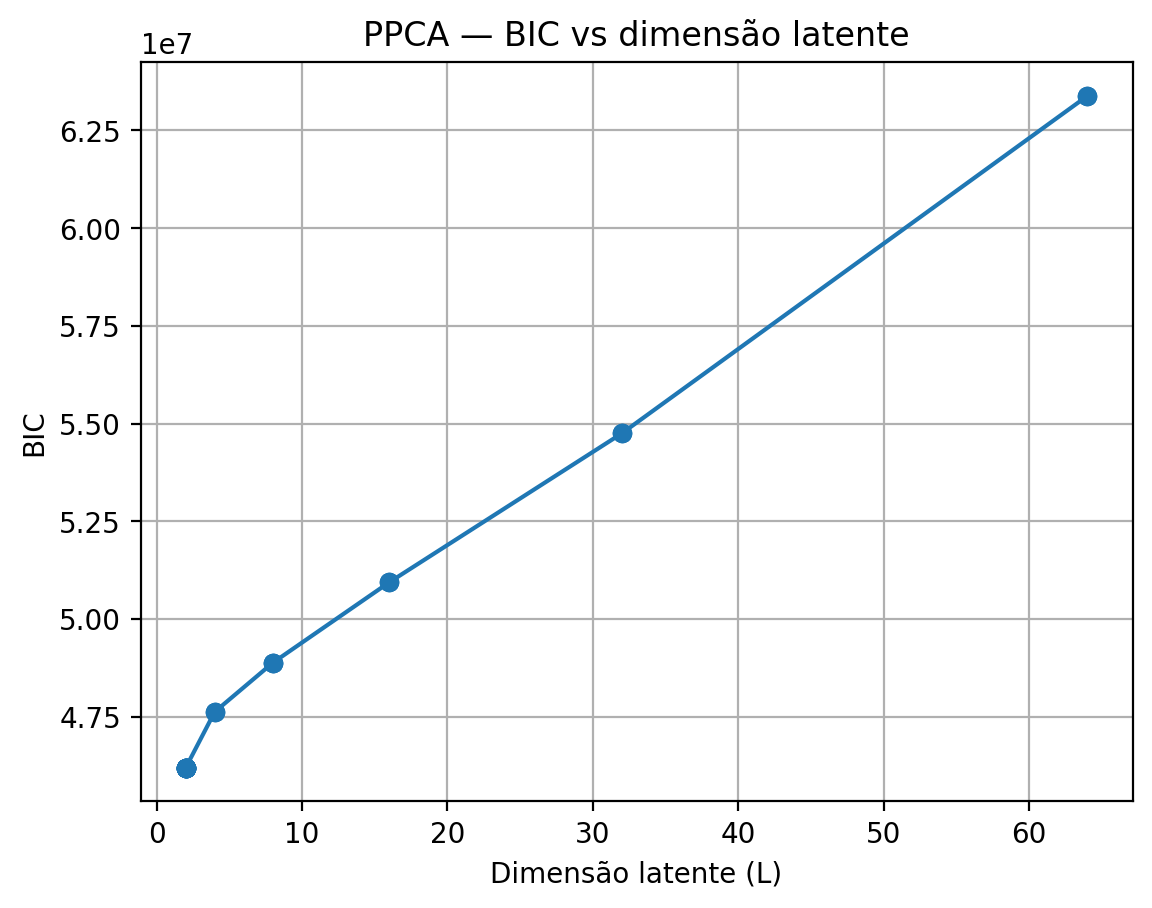

Melhor L: 2
Melhor BIC: 46192586.08513025


In [ ]:
Ls = []
BICs = []

for t in study.trials:
    if t.value is not None:
        Ls.append(t.user_attrs["latent_dim"])
        BICs.append(t.user_attrs["bic"])

Ls = np.array(Ls)
BICs = np.array(BICs)

# Ordenar por L para visualização limpa
order = np.argsort(Ls)
Ls = Ls[order]
BICs = BICs[order]

plt.figure()
plt.plot(Ls, BICs, marker="o")
plt.xlabel("Dimensão latente (L)")
plt.ylabel("BIC")
plt.title("PPCA — BIC vs dimensão latente")
plt.grid(True)
plt.show()

best_trial = study.best_trial

best_L = best_trial.user_attrs["latent_dim"]
W_best = best_trial.user_attrs["W"]
sigma2_best = best_trial.user_attrs["sigma2"]
u_best = best_trial.user_attrs["mean"]

print("Melhor L:", best_L)
print("Melhor BIC:", best_trial.value)

### Geração de dados PPCA

In [ ]:
def sample_ppca(
    W,
    sigma2,
    u,
    n_samples,
    window_size=96,
    num_channels=4,
    clip=True
):

    D, L = W.shape
    assert D == window_size * num_channels

    Z = np.random.randn(n_samples, L)

    eps = np.random.randn(n_samples, D) * np.sqrt(sigma2)

    X = Z @ W.T + u + eps

    X = X.reshape(n_samples, window_size, num_channels)

    if clip:
        X = np.clip(X, 0, None)

    return X

# Gerando 100 novos windows
X_gen = sample_ppca(
    W=W_best,
    sigma2=sigma2_best,
    u=u_best,
    n_samples=100
)

#clipando para valores inteiros
X_gen = np.clip(
    np.rint(X_gen),
    0,
    np.clip(X_gen, 0, 127)
).astype(np.int64)

print(X_gen.shape)

(100, 96, 4)


In [ ]:
# gerando varios samples para fazer o comparativo com as metricas
ppca_samples = []
for _ in range(1000):
    X_gen = sample_ppca(
        W=W_best,
        sigma2=sigma2_best,
        u=u_best,
        n_samples=15
    )

    #clipando para valores inteiros
    X_gen = np.clip(
        np.rint(X_gen),
        0,
        np.clip(X_gen, 0, 127)
    ).astype(np.int64)

    ppca_samples.append(X_gen)

In [ ]:
ppca_piano_roll_samples = []
for sample in ppca_samples:
    normalized_sample = windows_to_score_overlap(sample, stride = 24)
    final_sample = remove_short_notes(normalized_sample, min_duration= 2)
    ppca_piano_roll_samples.append(final_sample)

np.save("ppca_samples", ppca_piano_roll_samples)

## Variational Autoencoder

### Definição da classe

In [ ]:
batch_size = 512
learning_rate = 5*1e-3
num_epochs = 30
latent_dim = 2
hidden_dim = [512, 256]


In [ ]:
@dataclass
class LstmVAEOutput:
    """
    Classe modelo de saída do modelo
    """
    z_dist: torch.distributions.Distribution
    z_sample: torch.Tensor
    x_recon: torch.Tensor

    loss: torch.Tensor
    loss_recon: torch.Tensor
    loss_kl: torch.Tensor

class LstmVAE(nn.Module):
    """
    LSTM Variational Autoencoder (VAE)

    Args:
        input_dim (int): número de canais de áudio (e.g., 4 for NES).
        hidden_dim (int): dimensionalidade do hidden state do LSTM
        latent_dim (int): dimensionalidade do espaço latente
        seq_len (int): tamanho da sequência
        num_layers (int): número de camadas LSTM
    """

    def __init__(self, input_dim, hidden_dim, latent_dim, seq_len, num_layers=1):
        super(LstmVAE, self).__init__()

        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.latent_dim = latent_dim
        self.seq_len = seq_len
        self.num_layers = num_layers

        # ================= ENCODER =================
        # uso do LSTM do pytorch para dados sequenciais
        self.encoder_lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)

        # projeta o hidden state final -> 2 * latent_dim (Mean + LogVar)
        self.hidden_to_params = nn.Linear(hidden_dim, 2 * latent_dim)

        # ================= DECODER =================
        # projeta o z de volta ao tamanho do hidden state inicial do LSTM
        self.decoder_z_to_h = nn.Linear(latent_dim, hidden_dim)

        # LSTM para reconstrução
        self.decoder_lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)

        # camada de output para mapear pros canais do input_dim
        self.decoder_out = nn.Linear(hidden_dim, input_dim)

        print(f"LstmVAE Initialized: Input={input_dim}, Hidden={hidden_dim}, Latent={latent_dim}, SeqLen={seq_len}")

    def encode(self, x, eps: float = 1e-8):
        """
        Codifica a entrada para uma distribuição normal multivariacional.
        """
        # x shape: (Batch, Seq_Len, Input_Dim)

        # LSTM pela sequência
        _, (h_n, _) = self.encoder_lstm(x)

        # h_n shape: (num_layers, batch, hidden_dim).
        # usamos a útima camada do hidden state como sumário da sequência.
        h_n = h_n[-1]

        # projetar para parâmetros da distribuição
        params = self.hidden_to_params(h_n)
        mu, log_var = torch.chunk(params, 2, dim=-1)

        # criar distribuição com covariância diagonal
        var = torch.exp(log_var) + eps
        cov_matrix = torch.diag_embed(var)

        return torch.distributions.MultivariateNormal(loc=mu, covariance_matrix=cov_matrix)

    def reparameterize(self, dist):
        """
        Amostra z da distribuição usando o reparameterization trick.
        """
        return dist.rsample()

    def decode(self, z, x_target=None):
        """
        Decodifica z de volta para sequência
        """
        batch_size = z.size(0)
        device = z.device

        # Mapeia o vetor latente `z` para o estado oculto inicial (`h_0`) do LSTM do decodificador.
        # Ele é repetido para corresponder à forma (num_layers, batch, hidden_dim).
        h_0 = self.decoder_z_to_h(z).unsqueeze(0).repeat(self.num_layers, 1, 1)
        c_0 = torch.zeros_like(h_0)
        hidden = (h_0, c_0)

        if x_target is not None:
            out, _ = self.decoder_lstm(x_target, hidden)
            recon_x = self.decoder_out(out)
            return torch.sigmoid(recon_x)

        else:
            # MODO GERAÇÃO (Autoregressivo)
            outputs = []
            decoder_input = torch.zeros(batch_size, 1, self.input_dim).to(device)

            for _ in range(self.seq_len):
                out, hidden = self.decoder_lstm(decoder_input, hidden)
                step_out = self.decoder_out(out)

                step_out = torch.sigmoid(step_out)

                outputs.append(step_out)
                decoder_input = step_out

            return torch.cat(outputs, dim=1)

    def forward(self, x, compute_loss: bool = True):
        """
        Orquestra a passagem do VAE e calcula a loss se solicitado.
        """
        # 1. Codificar
        dist = self.encode(x)

        # 2. Reparametrizar
        z = self.reparameterize(dist)

        # 3. Decodificar
        # Durante o treinamento (forward), passamos 'x' para Teacher Forcing
        recon_x = self.decode(z, x_target=x)

        if not compute_loss:
            return LstmVAEOutput(
                z_dist=dist,
                z_sample=z,
                x_recon=recon_x,
                loss=None,
                loss_recon=None,
                loss_kl=None,
            )

        # 4. Calcular loss
        # Soma ao longo do comprimento da sequência e canais, média ao longo do batch
        loss_recon = F.mse_loss(recon_x, x, reduction='none').sum(dim=[1, 2]).mean()

        # Divergência KL
        # Compara a distribuição aprendida com a Normal Padrão (0, I)
        std_normal = torch.distributions.MultivariateNormal(
            torch.zeros_like(z, device=z.device),
            scale_tril=torch.eye(z.shape[-1], device=z.device).unsqueeze(0).expand(z.shape[0], -1, -1),
        )
        loss_kl = torch.distributions.kl.kl_divergence(dist, std_normal).mean()

        loss = loss_recon + loss_kl

        return LstmVAEOutput(
            z_dist=dist,
            z_sample=z,
            x_recon=recon_x,
            loss=loss,
            loss_recon=loss_recon,
            loss_kl=loss_kl,
        )

In [ ]:
class NESMusicDataset(Dataset):
    def __init__(self, data):
        # Converte para float32
        self.data = torch.tensor(data, dtype=torch.float32)

        # Normaliza os dados para o intervalo [0, 1]
        # Assumindo 128 como valor máximo teórico de notas (MIDI padrão)
        self.max_val = 127.0
        self.data = self.data / self.max_val

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], idx

# Carregar dados do arquivo npz
print("Carregando dados do arquivo nes_dataset_windows.npz...")
data = np.load("nes_dataset_windows.npz")

X_train = data['X_train'][:len(data['X_train'])//2]
X_test = data['X_test'][:len(data['X_test'])//2]
X_valid = data['X_valid'][:len(data['X_valid'])//2]

print(f"X_train shape: {X_train.shape} (50% dos dados)")
print(f"X_test shape: {X_test.shape}")
print(f"X_valid shape: {X_valid.shape}")

# Extrair dimensões do dataset
input_dim = X_train.shape[2]  # Número de canais (4 para NES)
seq_len = X_train.shape[1]    # Tamanho da sequência (96)

print(f"\nDimensões extraídas:")
print(f"  - input_dim (canais): {input_dim}")
print(f"  - seq_len (timesteps): {seq_len}")

# Criar datasets
train_dataset = NESMusicDataset(X_train)
test_dataset = NESMusicDataset(X_test)
valid_dataset = NESMusicDataset(X_valid)

# Criar dataloaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"\nDataLoaders criados:")
print(f"  - Train: {len(train_loader)} batches")
print(f"  - Test: {len(test_loader)} batches")
print(f"  - Valid: {len(valid_loader)} batches")

Carregando dados do arquivo nes_dataset_windows.npz...
X_train shape: (65021, 96, 4) (50% dos dados)
X_test shape: (3763, 96, 4)
X_valid shape: (4855, 96, 4)

Dimensões extraídas:
  - input_dim (canais): 4
  - seq_len (timesteps): 96

DataLoaders criados:
  - Train: 127 batches
  - Test: 8 batches
  - Valid: 10 batches


### Função de treino

In [ ]:
def train(model, dataloader, optimizer, prev_updates):
    """
    Treina o modelo nos dados fornecidos.

    Args:
        model (nn.Module): O modelo a ser treinado.
        dataloader (torch.utils.data.DataLoader): O data loader.
        optimizer: O otimizador.
        prev_updates: Número de atualizações anteriores.

    Returns:
        Tupla com (total_updates, loss_history)
    """
    model.train()  # Modo de treinamento

    loss_history = []
    recon_loss_history = []
    kl_loss_history = []

    for batch_idx, (data, _) in enumerate(tqdm(dataloader, desc='Training')):
        n_upd = prev_updates + batch_idx

        data = data.to(device)

        optimizer.zero_grad()  # Zerar gradientes

        output = model(data)  # Forward pass

        loss = output.loss
        loss.backward()

        optimizer.step()  # Atualizar parâmetros

        loss_history.append(loss.item())
        recon_loss_history.append(output.loss_recon.item())
        kl_loss_history.append(output.loss_kl.item())

    print(f'Step {n_upd:,} (N samples: {n_upd*batch_size:,})')
    print(f'  Train Loss: {np.mean(loss_history):.4f} | Recon: {np.mean(recon_loss_history):.4f} | KL: {np.mean(kl_loss_history):.4f}')

    return prev_updates + len(dataloader), loss_history


def evaluate(model, dataloader, dataset_name="Test"):
    """
    Avalia o modelo nos dados fornecidos.

    Args:
        model (nn.Module): O modelo a ser avaliado.
        dataloader (torch.utils.data.DataLoader): O data loader.
        dataset_name (str): Nome do dataset para exibição.

    Returns:
        Loss média do dataset.
    """
    model.eval()  # Modo de avaliação
    total_loss = 0
    total_recon_loss = 0
    total_kl_loss = 0

    with torch.no_grad():
        for data, _ in tqdm(dataloader, desc=f'Evaluating {dataset_name}'):
            data = data.to(device)

            output = model(data, compute_loss=True)  # Forward pass

            total_loss += output.loss.item()
            total_recon_loss += output.loss_recon.item()
            total_kl_loss += output.loss_kl.item()

    avg_loss = total_loss / len(dataloader)
    avg_recon = total_recon_loss / len(dataloader)
    avg_kl = total_kl_loss / len(dataloader)

    print(f'====> {dataset_name} Loss: {avg_loss:.4f} | Recon: {avg_recon:.4f} | KL: {avg_kl:.4f}')

    return avg_loss

### Otimização

In [ ]:
def create_model_for_trial(trial, input_dim, seq_len, device):
    """
    Cria um modelo com hiperparâmetros sugeridos pelo Optuna.
    """
    # Hiperparâmetros a otimizar
    hidden_dim = trial.suggest_categorical('hidden_dim', [128, 256, 512])
    latent_dim = trial.suggest_int('latent_dim', 2, 64)
    num_layers = trial.suggest_int('num_layers', 1, 3)
    learning_rate = trial.suggest_float('learning_rate', 1e-5, 1e-2, log=True)

    model = LstmVAE(
        input_dim=input_dim,
        hidden_dim=hidden_dim,
        latent_dim=latent_dim,
        seq_len=seq_len,
        num_layers=num_layers
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

    return model, optimizer


def objective(trial):
    """
    Função objetivo para o Optuna otimizar.
    """
    # Criar modelo com hiperparâmetros do trial
    model, optimizer = create_model_for_trial(trial, input_dim, seq_len, device)

    n_epochs_optuna = trial.suggest_int('n_epochs', 5, 15)

    for epoch in range(n_epochs_optuna):
        model.train()
        train_losses = []

        for batch_idx, (data, _) in enumerate(train_loader):
            data = data.to(device)
            optimizer.zero_grad()
            output = model(data)
            loss = output.loss
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        # Validação
        model.eval()
        valid_loss = 0
        with torch.no_grad():
            for data, _ in valid_loader:
                data = data.to(device)
                output = model(data, compute_loss=True)
                valid_loss += output.loss.item()

        valid_loss /= len(valid_loader)

        # Reportar valor intermediário para pruning
        trial.report(valid_loss, epoch)

        # Pruning: parar trials que não são promissores
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return valid_loss


def run_hyperparameter_optimization(n_trials=50, timeout=1800, study_name='lstm_vae_optimization'):
    """
    Executa a otimização de hiperparâmetros.

    Args:
        n_trials: Número máximo de trials
        timeout: Tempo máximo em segundos
        study_name: Nome do estudo Optuna

    Returns:
        study: O estudo Optuna com os resultados
    """
    # Criar sampler e pruner
    sampler = optuna.samplers.TPESampler(seed=42)
    pruner = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=3)

    # Criar estudo
    study = optuna.create_study(
        study_name=study_name,
        direction='minimize',
        sampler=sampler,
        pruner=pruner
    )

    # Otimizar
    print(f"Iniciando otimização com {n_trials} trials (timeout: {timeout}s)...")
    print("="*60)

    study.optimize(
        objective,
        n_trials=n_trials,
        timeout=timeout,
        show_progress_bar=True
    )

    # Resultados
    print("\n" + "="*60)
    print("="*60)
    print(f"Melhor valor de validação: {study.best_value:.4f}")
    print(f"Melhores hiperparâmetros:")
    for key, value in study.best_params.items():
        print(f"  - {key}: {value}")

    return study

In [ ]:
study = run_hyperparameter_optimization(n_trials=3, timeout=180)

# Visualização dos resultados do Optuna
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histórico de otimização
ax1 = axes[0, 0]
trials_df = study.trials_dataframe()
completed_trials = trials_df[trials_df['state'] == 'COMPLETE']
ax1.plot(completed_trials.index, completed_trials['value'], 'b-o', alpha=0.7, markersize=4)
ax1.axhline(y=study.best_value, color='r', linestyle='--', label=f'Melhor: {study.best_value:.4f}')
ax1.set_xlabel('Trial')
ax1.set_ylabel('Validation Loss')
ax1.set_title('Histórico de Otimização')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Importância dos hiperparâmetros
ax2 = axes[0, 1]
try:
    importances = optuna.importance.get_param_importances(study)
    params = list(importances.keys())
    values = list(importances.values())
    ax2.barh(params, values, color='steelblue')
    ax2.set_xlabel('Importância')
    ax2.set_title('Importância dos Hiperparâmetros')
except:
    ax2.text(0.5, 0.5, 'Necessário mais trials\npara calcular importância',
             ha='center', va='center', transform=ax2.transAxes)
    ax2.set_title('Importância dos Hiperparâmetros')

# Distribuição de hidden_dim vs loss
ax3 = axes[1, 0]
if 'params_hidden_dim' in completed_trials.columns:
    ax3.scatter(completed_trials['params_hidden_dim'], completed_trials['value'],
                alpha=0.6, c='steelblue', edgecolors='black', linewidth=0.5)
    ax3.set_xlabel('Hidden Dim')
    ax3.set_ylabel('Validation Loss')
    ax3.set_title('Hidden Dim vs Loss')
    ax3.grid(True, alpha=0.3)

# Distribuição de latent_dim vs loss
ax4 = axes[1, 1]
if 'params_latent_dim' in completed_trials.columns:
    ax4.scatter(completed_trials['params_latent_dim'], completed_trials['value'],
                alpha=0.6, c='coral', edgecolors='black', linewidth=0.5)
    ax4.set_xlabel('Latent Dim')
    ax4.set_ylabel('Validation Loss')
    ax4.set_title('Latent Dim vs Loss')
    ax4.grid(True, alpha=0.3)

plt.suptitle('Análise da Otimização de Hiperparâmetros - Optuna', fontsize=14)
plt.tight_layout()
plt.show()

# Mostrar tabela com os melhores trials
print("\n" + "="*60)
print("MELHORES TRIALS")
print("="*60)
top_trials = completed_trials.nsmallest(5, 'value')[['number', 'value', 'params_hidden_dim',
                                                       'params_latent_dim', 'params_num_layers',
                                                       'params_learning_rate']]
print(top_trials.to_string(index=False))

[I 2026-01-07 18:14:05,535] A new study created in memory with name: lstm_vae_optimization


Iniciando otimização com 3 trials (timeout: 180s)...


  0%|          | 0/3 [00:00<?, ?it/s]

LstmVAE Initialized: Input=4, Hidden=256, Latent=39, SeqLen=96
[I 2026-01-07 18:14:58,238] Trial 0 finished with value: 11.127216148376466 and parameters: {'hidden_dim': 256, 'latent_dim': 39, 'num_layers': 1, 'learning_rate': 2.9375384576328295e-05, 'n_epochs': 5}. Best is trial 0 with value: 11.127216148376466.
LstmVAE Initialized: Input=4, Hidden=128, Latent=3, SeqLen=96
[I 2026-01-07 18:16:42,167] Trial 1 finished with value: 0.17454342991113664 and parameters: {'hidden_dim': 128, 'latent_dim': 3, 'num_layers': 3, 'learning_rate': 0.00314288089084011, 'n_epochs': 7}. Best is trial 1 with value: 0.17454342991113664.
LstmVAE Initialized: Input=4, Hidden=512, Latent=35, SeqLen=96
[I 2026-01-07 18:31:31,995] Trial 2 finished with value: 2.8299591183662414 and parameters: {'hidden_dim': 512, 'latent_dim': 35, 'num_layers': 2, 'learning_rate': 7.476312062252303e-05, 'n_epochs': 11}. Best is trial 1 with value: 0.17454342991113664.

Melhor valor de validação: 0.1745
Melhores hiperparâmetr

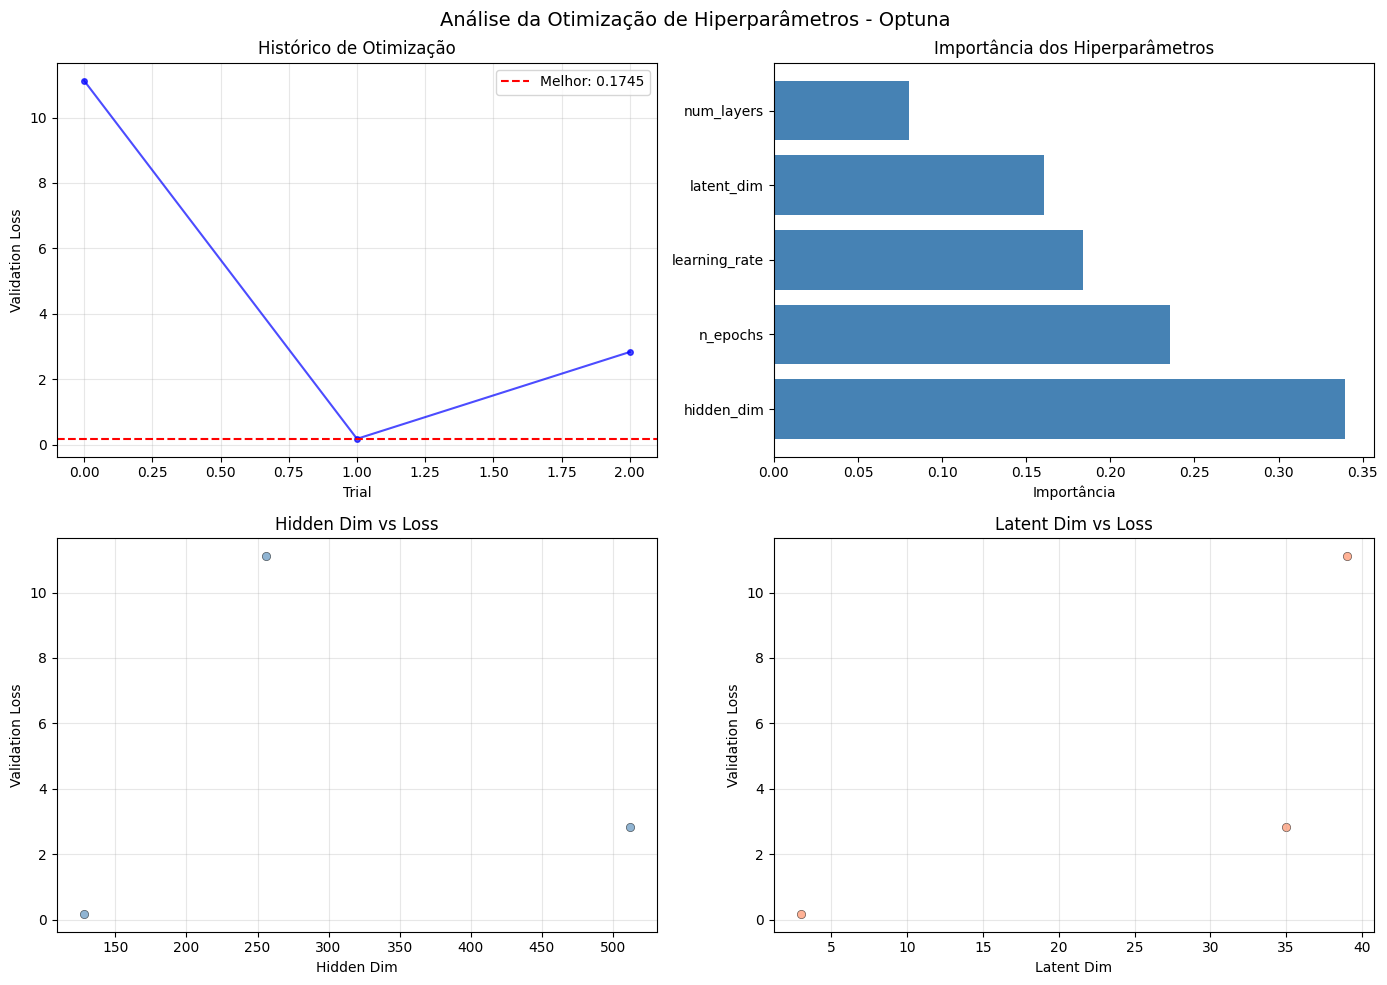


MELHORES TRIALS
 number     value  params_hidden_dim  params_latent_dim  params_num_layers  params_learning_rate
      1  0.174543                128                  3                  3              0.003143
      2  2.829959                512                 35                  2              0.000075
      0 11.127216                256                 39                  1              0.000029


In [ ]:
study = run_hyperparameter_optimization(n_trials=3, timeout=180)

# Visualização dos resultados do Optuna
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histórico de otimização
ax1 = axes[0, 0]
trials_df = study.trials_dataframe()
completed_trials = trials_df[trials_df['state'] == 'COMPLETE']
ax1.plot(completed_trials.index, completed_trials['value'], 'b-o', alpha=0.7, markersize=4)
ax1.axhline(y=study.best_value, color='r', linestyle='--', label=f'Melhor: {study.best_value:.4f}')
ax1.set_xlabel('Trial')
ax1.set_ylabel('Validation Loss')
ax1.set_title('Histórico de Otimização')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Importância dos hiperparâmetros
ax2 = axes[0, 1]
try:
    importances = optuna.importance.get_param_importances(study)
    params = list(importances.keys())
    values = list(importances.values())
    ax2.barh(params, values, color='steelblue')
    ax2.set_xlabel('Importância')
    ax2.set_title('Importância dos Hiperparâmetros')
except:
    ax2.text(0.5, 0.5, 'Necessário mais trials\npara calcular importância',
             ha='center', va='center', transform=ax2.transAxes)
    ax2.set_title('Importância dos Hiperparâmetros')

# Distribuição de hidden_dim vs loss
ax3 = axes[1, 0]
if 'params_hidden_dim' in completed_trials.columns:
    ax3.scatter(completed_trials['params_hidden_dim'], completed_trials['value'],
                alpha=0.6, c='steelblue', edgecolors='black', linewidth=0.5)
    ax3.set_xlabel('Hidden Dim')
    ax3.set_ylabel('Validation Loss')
    ax3.set_title('Hidden Dim vs Loss')
    ax3.grid(True, alpha=0.3)

# Distribuição de latent_dim vs loss
ax4 = axes[1, 1]
if 'params_latent_dim' in completed_trials.columns:
    ax4.scatter(completed_trials['params_latent_dim'], completed_trials['value'],
                alpha=0.6, c='coral', edgecolors='black', linewidth=0.5)
    ax4.set_xlabel('Latent Dim')
    ax4.set_ylabel('Validation Loss')
    ax4.set_title('Latent Dim vs Loss')
    ax4.grid(True, alpha=0.3)

plt.suptitle('Análise da Otimização de Hiperparâmetros - Optuna', fontsize=14)
plt.tight_layout()
plt.show()

# Mostrar tabela com os melhores trials
print("\n" + "="*60)
print("MELHORES TRIALS")
print("="*60)
top_trials = completed_trials.nsmallest(5, 'value')[['number', 'value', 'params_hidden_dim',
                                                       'params_latent_dim', 'params_num_layers',
                                                       'params_learning_rate']]
print(top_trials.to_string(index=False))

In [ ]:
# Usar os melhores hiperparâmetros encontrados pelo Optuna
best_params = study.best_params
print("Treinando modelo com os melhores hiperparâmetros encontrados:")
print(f"  - hidden_dim: {best_params['hidden_dim']}")
print(f"  - latent_dim: {best_params['latent_dim']}")
print(f"  - num_layers: {best_params['num_layers']}")
print(f"  - learning_rate: {best_params['learning_rate']:.6f}")
print("-" * 60)

model_optimized = LstmVAE(
    input_dim=input_dim,
    hidden_dim=best_params['hidden_dim'],
    latent_dim=best_params['latent_dim'],
    seq_len=seq_len,
    num_layers=best_params['num_layers']
).to(device)

print(model_optimized)
print(f"\nTotal de parâmetros: {sum(p.numel() for p in model_optimized.parameters()):,}")

optimizer_opt = torch.optim.AdamW(model_optimized.parameters(), lr=best_params['learning_rate'])

train_loss_history_opt = []
valid_loss_history_opt = []
test_loss_history_opt = []

prev_updates_opt = 0

num_epochs_optimized = 15

for epoch in range(num_epochs_optimized):
    print(f'\nEpoch {epoch+1}/{num_epochs_optimized}')

    prev_updates_opt, train_loss = train(model_optimized, train_loader, optimizer_opt, prev_updates_opt)
    train_loss_history_opt.append(np.mean(train_loss))

    valid_loss = evaluate(model_optimized, valid_loader, dataset_name="Validation")
    valid_loss_history_opt.append(valid_loss)

    test_loss = evaluate(model_optimized, test_loader, dataset_name="Test")
    test_loss_history_opt.append(test_loss)

print(f'\n{"="*60}')
print("Treinamento do modelo otimizado concluído!")
print(f'Melhor Valid Loss: {min(valid_loss_history_opt):.4f} (Epoch {valid_loss_history_opt.index(min(valid_loss_history_opt))+1})')

# Comparação com modelo original
print(f'\n--- Comparação ---')
if 'valid_loss_history' in globals():
    print(f'Modelo Original - Melhor Valid Loss: {min(valid_loss_history):.4f}')
    print(f'Modelo Otimizado - Melhor Valid Loss: {min(valid_loss_history_opt):.4f}')
    improvement = ((min(valid_loss_history) - min(valid_loss_history_opt)) / min(valid_loss_history)) * 100
    print(f'Melhoria: {improvement:.2f}%')
elif 'valid_loss_history_opt' in globals(): # Fallback if original is not found, but optimized is
    print("Resultados do 'Modelo Original' (valid_loss_history) não encontrados.")
    print("Certifique-se de que a célula de treinamento do modelo original foi executada com sucesso.")
    print(f'Modelo Otimizado - Melhor Valid Loss: {min(valid_loss_history_opt):.4f}')
else:
    print("Nenhum resultado de treinamento (original ou otimizado) encontrado para comparação.")

In [ ]:
# Usar os melhores hiperparâmetros encontrados pelo Optuna
best_params = study.best_params
print("Treinando modelo com os melhores hiperparâmetros encontrados:")
print(f"  - hidden_dim: {best_params['hidden_dim']}")
print(f"  - latent_dim: {best_params['latent_dim']}")
print(f"  - num_layers: {best_params['num_layers']}")
print(f"  - learning_rate: {best_params['learning_rate']:.6f}")
print("-" * 60)

model_optimized = LstmVAE(
    input_dim=input_dim,
    hidden_dim=best_params['hidden_dim'],
    latent_dim=best_params['latent_dim'],
    seq_len=seq_len,
    num_layers=best_params['num_layers']
).to(device)

print(model_optimized)
print(f"\nTotal de parâmetros: {sum(p.numel() for p in model_optimized.parameters()):,}")

optimizer_opt = torch.optim.AdamW(model_optimized.parameters(), lr=best_params['learning_rate'])

train_loss_history_opt = []
valid_loss_history_opt = []
test_loss_history_opt = []

prev_updates_opt = 0

num_epochs_optimized = 15

for epoch in range(num_epochs_optimized):
    print(f'\nEpoch {epoch+1}/{num_epochs_optimized}')

    prev_updates_opt, train_loss = train(model_optimized, train_loader, optimizer_opt, prev_updates_opt)
    train_loss_history_opt.append(np.mean(train_loss))

    valid_loss = evaluate(model_optimized, valid_loader, dataset_name="Validation")
    valid_loss_history_opt.append(valid_loss)

    test_loss = evaluate(model_optimized, test_loader, dataset_name="Test")
    test_loss_history_opt.append(test_loss)

print(f'\n{"="*60}')
print("Treinamento do modelo otimizado concluído!")
print(f'Melhor Valid Loss: {min(valid_loss_history_opt):.4f} (Epoch {valid_loss_history_opt.index(min(valid_loss_history_opt))+1})')

# Comparação com modelo original
print(f'\n--- Comparação ---')
if 'valid_loss_history' in globals():
    print(f'Modelo Original - Melhor Valid Loss: {min(valid_loss_history):.4f}')
    print(f'Modelo Otimizado - Melhor Valid Loss: {min(valid_loss_history_opt):.4f}')
    improvement = ((min(valid_loss_history) - min(valid_loss_history_opt)) / min(valid_loss_history)) * 100
    print(f'Melhoria: {improvement:.2f}%')
elif 'valid_loss_history_opt' in globals(): # Fallback if original is not found, but optimized is
    print("Resultados do 'Modelo Original' (valid_loss_history) não encontrados.")
    print("Certifique-se de que a célula de treinamento do modelo original foi executada com sucesso.")
    print(f'Modelo Otimizado - Melhor Valid Loss: {min(valid_loss_history_opt):.4f}')
else:
    print("Nenhum resultado de treinamento (original ou otimizado) encontrado para comparação.")

Treinando modelo com os melhores hiperparâmetros encontrados:
  - hidden_dim: 128
  - latent_dim: 3
  - num_layers: 3
  - learning_rate: 0.003143
------------------------------------------------------------
LstmVAE Initialized: Input=4, Hidden=128, Latent=3, SeqLen=96
LstmVAE(
  (encoder_lstm): LSTM(4, 128, num_layers=3, batch_first=True)
  (hidden_to_params): Linear(in_features=128, out_features=6, bias=True)
  (decoder_z_to_h): Linear(in_features=3, out_features=128, bias=True)
  (decoder_lstm): LSTM(4, 128, num_layers=3, batch_first=True)
  (decoder_out): Linear(in_features=128, out_features=4, bias=True)
)

Total de parâmetros: 667,402

Epoch 1/15


Training:   0%|          | 0/127 [00:00<?, ?it/s]

Step 126 (N samples: 64,512)
  Train Loss: 10.2784 | Recon: 10.2775 | KL: 0.0009


Evaluating Validation:   0%|          | 0/10 [00:00<?, ?it/s]

====> Validation Loss: 8.6542 | Recon: 8.6542 | KL: 0.0000


...

Step 1,904 (N samples: 974,848)
  Train Loss: 0.0184 | Recon: 0.0184 | KL: 0.0000


Evaluating Validation:   0%|          | 0/10 [00:00<?, ?it/s]

====> Validation Loss: 0.0122 | Recon: 0.0122 | KL: 0.0000


Evaluating Test:   0%|          | 0/8 [00:00<?, ?it/s]

====> Test Loss: 0.0088 | Recon: 0.0088 | KL: 0.0000

Treinamento do modelo otimizado concluído!
Melhor Valid Loss: 0.0122 (Epoch 15)

--- Comparação ---
Resultados do 'Modelo Original' (valid_loss_history) não encontrados.
Certifique-se de que a célula de treinamento do modelo original foi executada com sucesso.
Modelo Otimizado - Melhor Valid Loss: 0.0122


In [ ]:
print("Inicializando LSTM Variational Autoencoder...")
print(f"Configurações: latent_dim={latent_dim}, hidden_dim={hidden_dim[0]}, num_epochs={num_epochs}")
print(f"Device: {device}")
print("-" * 60)

# Criar modelo usando hidden_dim[0] como dimensão oculta do LSTM
model_LSTM_VAE = LstmVAE(
    input_dim=input_dim,
    hidden_dim=hidden_dim[0],
    latent_dim=latent_dim,
    seq_len=seq_len,
    num_layers=1
).to(device)

print(model_LSTM_VAE)
print(f"\nTotal de parâmetros: {sum(p.numel() for p in model_LSTM_VAE.parameters()):,}")
print("-" * 60)

optimizer = torch.optim.AdamW(model_LSTM_VAE.parameters(), lr=learning_rate)

train_loss_history = []
valid_loss_history = []
test_loss_history = []

prev_updates = 0

for epoch in range(num_epochs):
    print(f'\n{"="*60}')
    print(f'Epoch {epoch+1}/{num_epochs}')
    print(f'{"="*60}')

    # Treinamento
    prev_updates, train_loss = train(model_LSTM_VAE, train_loader, optimizer, prev_updates)
    train_loss_history.append(np.mean(train_loss))

    # Validação
    valid_loss = evaluate(model_LSTM_VAE, valid_loader, dataset_name="Validation")
    valid_loss_history.append(valid_loss)

    # Teste
    test_loss = evaluate(model_LSTM_VAE, test_loader, dataset_name="Test")
    test_loss_history.append(test_loss)

print(f'\n{"="*60}')
print("Treinamento concluído!")
print(f'Melhor Valid Loss: {min(valid_loss_history):.4f} (Epoch {valid_loss_history.index(min(valid_loss_history))+1})')
print(f'{"="*60}')

In [ ]:
print("Inicializando LSTM Variational Autoencoder...")
print(f"Configurações: latent_dim={latent_dim}, hidden_dim={hidden_dim[0]}, num_epochs={num_epochs}")
print(f"Device: {device}")
print("-" * 60)

# Criar modelo usando hidden_dim[0] como dimensão oculta do LSTM
model_LSTM_VAE = LstmVAE(
    input_dim=input_dim,
    hidden_dim=hidden_dim[0],
    latent_dim=latent_dim,
    seq_len=seq_len,
    num_layers=1
).to(device)

print(model_LSTM_VAE)
print(f"\nTotal de parâmetros: {sum(p.numel() for p in model_LSTM_VAE.parameters()):,}")
print("-" * 60)

optimizer = torch.optim.AdamW(model_LSTM_VAE.parameters(), lr=learning_rate)

train_loss_history = []
valid_loss_history = []
test_loss_history = []

prev_updates = 0

for epoch in range(num_epochs):
    print(f'\n{"="*60}')
    print(f'Epoch {epoch+1}/{num_epochs}')
    print(f'{"="*60}')

    # Treinamento
    prev_updates, train_loss = train(model_LSTM_VAE, train_loader, optimizer, prev_updates)
    train_loss_history.append(np.mean(train_loss))

    # Validação
    valid_loss = evaluate(model_LSTM_VAE, valid_loader, dataset_name="Validation")
    valid_loss_history.append(valid_loss)

    # Teste
    test_loss = evaluate(model_LSTM_VAE, test_loader, dataset_name="Test")
    test_loss_history.append(test_loss)

print(f'\n{"="*60}')
print("Treinamento concluído!")
print(f'Melhor Valid Loss: {min(valid_loss_history):.4f} (Epoch {valid_loss_history.index(min(valid_loss_history))+1})')
print(f'{"="*60}')

Inicializando LSTM Variational Autoencoder...
Configurações: latent_dim=2, hidden_dim=512, num_epochs=30
Device: cuda
------------------------------------------------------------
LstmVAE Initialized: Input=4, Hidden=512, Latent=2, SeqLen=96
LstmVAE(
  (encoder_lstm): LSTM(4, 512, batch_first=True)
  (hidden_to_params): Linear(in_features=512, out_features=4, bias=True)
  (decoder_z_to_h): Linear(in_features=2, out_features=512, bias=True)
  (decoder_lstm): LSTM(4, 512, batch_first=True)
  (decoder_out): Linear(in_features=512, out_features=4, bias=True)
)

Total de parâmetros: 2,127,368
------------------------------------------------------------

Epoch 1/30


Training:   0%|          | 0/127 [00:00<?, ?it/s]

Step 126 (N samples: 64,512)
  Train Loss: 9.3304 | Recon: 9.3238 | KL: 0.0066


Evaluating Validation:   0%|          | 0/10 [00:00<?, ?it/s]

====> Validation Loss: 5.1445 | Recon: 5.1445 | KL: 0.0000


...

Step 3,809 (N samples: 1,950,208)
  Train Loss: 0.0241 | Recon: 0.0241 | KL: 0.0000


Evaluating Validation:   0%|          | 0/10 [00:00<?, ?it/s]

====> Validation Loss: 0.0256 | Recon: 0.0256 | KL: 0.0000


Evaluating Test:   0%|          | 0/8 [00:00<?, ?it/s]

====> Test Loss: 0.0183 | Recon: 0.0183 | KL: 0.0000

Treinamento concluído!
Melhor Valid Loss: 0.0256 (Epoch 30)


### Visualizações

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Todas as losses juntas
ax1 = axes[0]
epochs_range = range(1, len(train_loss_history) + 1)
ax1.plot(epochs_range, train_loss_history, label="Train Loss", marker='o', markersize=3)
ax1.plot(epochs_range, valid_loss_history, label="Validation Loss", marker='s', markersize=3)
ax1.plot(epochs_range, test_loss_history, label="Test Loss", marker='^', markersize=3)
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Loss")
ax1.set_title("LSTM VAE - Training Progress")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Train vs Validation
ax2 = axes[1]
ax2.plot(epochs_range, train_loss_history, label="Train Loss", color='blue', linewidth=2)
ax2.plot(epochs_range, valid_loss_history, label="Validation Loss", color='orange', linewidth=2)
ax2.fill_between(epochs_range, train_loss_history, valid_loss_history, alpha=0.2, color='gray')
ax2.set_xlabel("Epochs")
ax2.set_ylabel("Loss")
ax2.set_title("LSTM VAE - Train vs Validation")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("ESTATÍSTICAS FINAIS")
print("="*60)
print(f"Train Loss Final:      {train_loss_history[-1]:.4f}")
print(f"Validation Loss Final: {valid_loss_history[-1]:.4f}")
print(f"Test Loss Final:       {test_loss_history[-1]:.4f}")
print(f"Melhor Valid Loss:     {min(valid_loss_history):.4f} (Epoch {valid_loss_history.index(min(valid_loss_history))+1})")

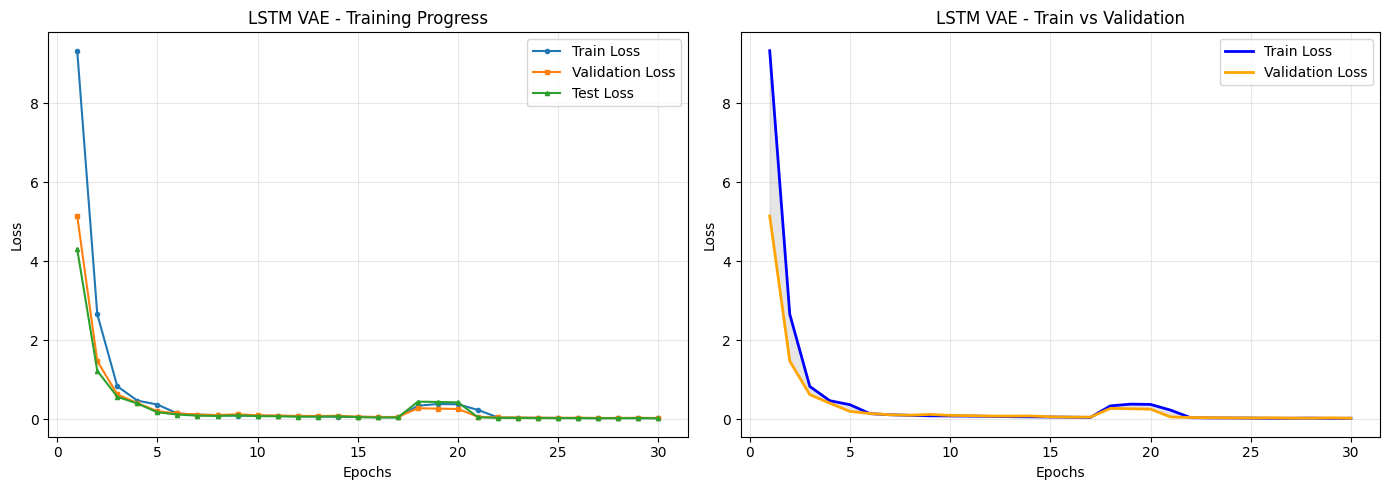


ESTATÍSTICAS FINAIS
Train Loss Final:      0.0241
Validation Loss Final: 0.0256
Test Loss Final:       0.0183
Melhor Valid Loss:     0.0256 (Epoch 30)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Todas as losses juntas
ax1 = axes[0]
epochs_range = range(1, len(train_loss_history) + 1)
ax1.plot(epochs_range, train_loss_history, label="Train Loss", marker='o', markersize=3)
ax1.plot(epochs_range, valid_loss_history, label="Validation Loss", marker='s', markersize=3)
ax1.plot(epochs_range, test_loss_history, label="Test Loss", marker='^', markersize=3)
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Loss")
ax1.set_title("LSTM VAE - Training Progress")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Train vs Validation
ax2 = axes[1]
ax2.plot(epochs_range, train_loss_history, label="Train Loss", color='blue', linewidth=2)
ax2.plot(epochs_range, valid_loss_history, label="Validation Loss", color='orange', linewidth=2)
ax2.fill_between(epochs_range, train_loss_history, valid_loss_history, alpha=0.2, color='gray')
ax2.set_xlabel("Epochs")
ax2.set_ylabel("Loss")
ax2.set_title("LSTM VAE - Train vs Validation")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("ESTATÍSTICAS FINAIS")
print("="*60)
print(f"Train Loss Final:      {train_loss_history[-1]:.4f}")
print(f"Validation Loss Final: {valid_loss_history[-1]:.4f}")
print(f"Test Loss Final:       {test_loss_history[-1]:.4f}")
print(f"Melhor Valid Loss:     {min(valid_loss_history):.4f} (Epoch {valid_loss_history.index(min(valid_loss_history))+1})")

In [ ]:
def generate_samples(model, num_samples=5, device='cuda', max_val=127.0):
    """
    Gera novas amostras de música a partir do espaço latente e desnormaliza.
    """
    model.eval()
    with torch.no_grad():
        # Amostrar z da distribuição prior (Normal padrão)
        z = torch.randn(num_samples, model.latent_dim).to(device)

        # Decodificar z para gerar sequências (modo autorregressivo)
        generated = model.decode(z, x_target=None)

        # Desnormalização
        generated = generated * max_val
        generated = torch.round(generated)

    return generated

# Gerar algumas amostras
print("Gerando amostras do modelo treinado...")
# Passamos o max_val igual ao usado no Dataset (128.0)
generated_samples = generate_samples(model_LSTM_VAE, num_samples=3, device=device, max_val=128.0)
print(f"Shape das amostras geradas: {generated_samples.shape}")

# Visualizar uma amostra gerada vs uma amostra real
fig, axes = plt.subplots(2, 4, figsize=(16, 6))

# Amostra real do dataset (X_train já está na escala 0-128 se lido direto do npz)
sample_real = X_train[np.random.randint(0, len(X_train))]
channel_names = ['Pulse 1', 'Pulse 2', 'Triangle', 'Noise']

# Definir limites fixos para o eixo Y para facilitar a comparação visual
y_min = 0
y_max = 130

for i in range(4):
    axes[0, i].plot(sample_real[:, i], color='blue', alpha=0.7)
    axes[0, i].set_title(f'Real - {channel_names[i]}')
    axes[0, i].set_xlabel('Time Step')
    axes[0, i].set_ylabel('Value (Pitch)')
    axes[0, i].set_ylim(y_min, y_max) # Força a escala correta
    axes[0, i].grid(True, alpha=0.3)

# Amostra gerada (agora desnormalizada)
sample_gen = generated_samples[0].cpu().numpy()
for i in range(4):
    axes[1, i].plot(sample_gen[:, i], color='red', alpha=0.7)
    axes[1, i].set_title(f'Gerada - {channel_names[i]}')
    axes[1, i].set_xlabel('Time Step')
    axes[1, i].set_ylabel('Value (Pitch)')
    axes[1, i].set_ylim(y_min, y_max) # Força a escala correta
    axes[1, i].grid(True, alpha=0.3)

plt.suptitle('Comparação: Amostra Real vs Gerada (Escala Original 0-128)', fontsize=14)
plt.tight_layout()
plt.show()

Gerando amostras do modelo treinado...
Shape das amostras geradas: torch.Size([3, 96, 4])


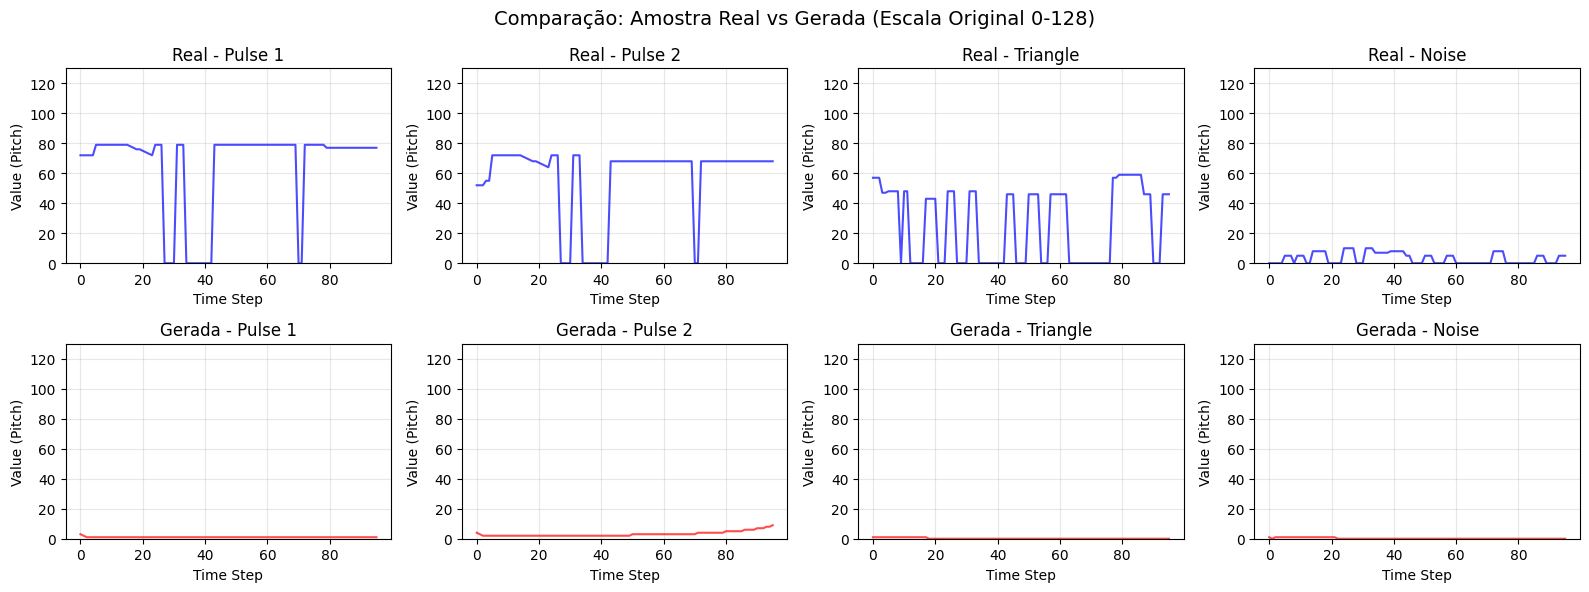

In [ ]:
def generate_samples(model, num_samples=5, device='cuda', max_val=127.0):
    """
    Gera novas amostras de música a partir do espaço latente e desnormaliza.
    """
    model.eval()
    with torch.no_grad():
        # Amostrar z da distribuição prior (Normal padrão)
        z = torch.randn(num_samples, model.latent_dim).to(device)

        # Decodificar z para gerar sequências (modo autorregressivo)
        generated = model.decode(z, x_target=None)

        # Desnormalização
        generated = generated * max_val
        generated = torch.round(generated)

    return generated

# Gerar algumas amostras
print("Gerando amostras do modelo treinado...")
# Passamos o max_val igual ao usado no Dataset (128.0)
generated_samples = generate_samples(model_LSTM_VAE, num_samples=3, device=device, max_val=128.0)
print(f"Shape das amostras geradas: {generated_samples.shape}")

# Visualizar uma amostra gerada vs uma amostra real
fig, axes = plt.subplots(2, 4, figsize=(16, 6))

# Amostra real do dataset (X_train já está na escala 0-128 se lido direto do npz)
sample_real = X_train[np.random.randint(0, len(X_train))]
channel_names = ['Pulse 1', 'Pulse 2', 'Triangle', 'Noise']

# Definir limites fixos para o eixo Y para facilitar a comparação visual
y_min = 0
y_max = 130

for i in range(4):
    axes[0, i].plot(sample_real[:, i], color='blue', alpha=0.7)
    axes[0, i].set_title(f'Real - {channel_names[i]}')
    axes[0, i].set_xlabel('Time Step')
    axes[0, i].set_ylabel('Value (Pitch)')
    axes[0, i].set_ylim(y_min, y_max) # Força a escala correta
    axes[0, i].grid(True, alpha=0.3)

# Amostra gerada (agora desnormalizada)
sample_gen = generated_samples[0].cpu().numpy()
for i in range(4):
    axes[1, i].plot(sample_gen[:, i], color='red', alpha=0.7)
    axes[1, i].set_title(f'Gerada - {channel_names[i]}')
    axes[1, i].set_xlabel('Time Step')
    axes[1, i].set_ylabel('Value (Pitch)')
    axes[1, i].set_ylim(y_min, y_max) # Força a escala correta
    axes[1, i].grid(True, alpha=0.3)

plt.suptitle('Comparação: Amostra Real vs Gerada (Escala Original 0-128)', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
def get_latent_representations(model, dataloader, device, max_samples=5000):
    """
    Obtém as representações latentes (z) para os dados.
    """
    model.eval()
    latent_vectors = []

    with torch.no_grad():
        for data, _ in tqdm(dataloader, desc='Encoding'):
            data = data.to(device)
            output = model(data, compute_loss=False)
            latent_vectors.append(output.z_sample.cpu().numpy())

            if sum(len(v) for v in latent_vectors) >= max_samples:
                break

    return np.concatenate(latent_vectors, axis=0)[:max_samples]

# Obter representações latentes do conjunto de validação
print("Obtendo representações latentes...")
z_valid = get_latent_representations(model_LSTM_VAE, valid_loader, device, max_samples=5000)
print(f"Shape das representações latentes: {z_valid.shape}")

# Visualizar espaço latente (funciona melhor com latent_dim=2)
if latent_dim == 2:
    plt.figure(figsize=(10, 8))
    plt.scatter(z_valid[:, 0], z_valid[:, 1], alpha=0.5, s=5)
    plt.xlabel('z[0]')
    plt.ylabel('z[1]')
    plt.title('Espaço Latente 2D - LSTM VAE')
    plt.grid(True, alpha=0.3)
    plt.colorbar(label='Densidade')
    plt.show()
else:

    pca = PCA(n_components=2)
    z_pca = pca.fit_transform(z_valid)

    plt.figure(figsize=(10, 8))
    plt.scatter(z_pca[:, 0], z_pca[:, 1], alpha=0.5, s=5)
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title(f'Espaço Latente (PCA 2D) - LSTM VAE (latent_dim={latent_dim})')
    plt.grid(True, alpha=0.3)
    plt.show()

    print(f"Variância explicada: {pca.explained_variance_ratio_.sum()*100:.2f}%")

Obtendo representações latentes...


Encoding:   0%|          | 0/10 [00:00<?, ?it/s]

Shape das representações latentes: (4855, 2)


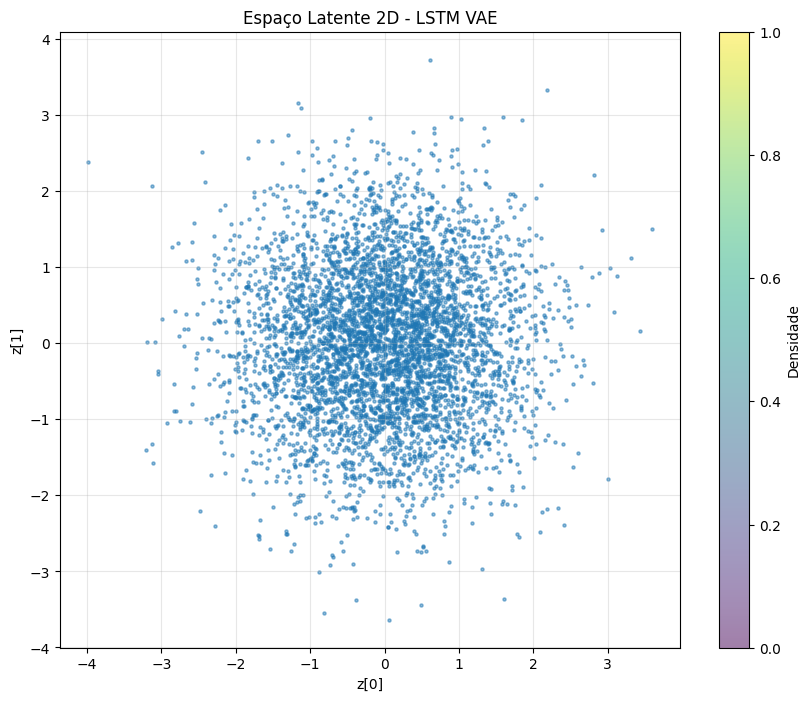

In [ ]:
def get_latent_representations(model, dataloader, device, max_samples=5000):
    """
    Obtém as representações latentes (z) para os dados.
    """
    model.eval()
    latent_vectors = []

    with torch.no_grad():
        for data, _ in tqdm(dataloader, desc='Encoding'):
            data = data.to(device)
            output = model(data, compute_loss=False)
            latent_vectors.append(output.z_sample.cpu().numpy())

            if sum(len(v) for v in latent_vectors) >= max_samples:
                break

    return np.concatenate(latent_vectors, axis=0)[:max_samples]

# Obter representações latentes do conjunto de validação
print("Obtendo representações latentes...")
z_valid = get_latent_representations(model_LSTM_VAE, valid_loader, device, max_samples=5000)
print(f"Shape das representações latentes: {z_valid.shape}")

# Visualizar espaço latente (funciona melhor com latent_dim=2)
if latent_dim == 2:
    plt.figure(figsize=(10, 8))
    plt.scatter(z_valid[:, 0], z_valid[:, 1], alpha=0.5, s=5)
    plt.xlabel('z[0]')
    plt.ylabel('z[1]')
    plt.title('Espaço Latente 2D - LSTM VAE')
    plt.grid(True, alpha=0.3)
    plt.colorbar(label='Densidade')
    plt.show()
else:

    pca = PCA(n_components=2)
    z_pca = pca.fit_transform(z_valid)

    plt.figure(figsize=(10, 8))
    plt.scatter(z_pca[:, 0], z_pca[:, 1], alpha=0.5, s=5)
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title(f'Espaço Latente (PCA 2D) - LSTM VAE (latent_dim={latent_dim})')
    plt.grid(True, alpha=0.3)
    plt.show()

    print(f"Variância explicada: {pca.explained_variance_ratio_.sum()*100:.2f}%")

## Avaliação do modelo



In [ ]:
model_LSTM_VAE = LstmVAE(input_dim= 4,
                         hidden_dim= 512,
                         latent_dim= 2,
                         seq_len= 96,
                         num_layers= 1)
model_LSTM_VAE.to(device)
state_dict = torch.load("vaeFinal.pth", map_location= "cuda")
model_LSTM_VAE.load_state_dict(state_dict)

model_LSTM_VAE.eval()

LstmVAE Initialized: Input=4, Hidden=512, Latent=2, SeqLen=96


C:\Users\caslu\AppData\Local\Temp\ipykernel_35156\2943494573.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load("vaeFinal.pth", map_location= "cuda"

LstmVAE(
  (encoder_lstm): LSTM(4, 512, batch_first=True)
  (hidden_to_params): Linear(in_features=512, out_features=4, bias=True)
  (decoder_z_to_h): Linear(in_features=2, out_features=512, bias=True)
  (decoder_lstm): LSTM(4, 512, batch_first=True)
  (decoder_out): Linear(in_features=512, out_features=4, bias=True)
)

In [ ]:
vae_samples = []
for _ in range(1000):
    X_gen = generate_samples(model_LSTM_VAE, num_samples= 15).to("cpu")
    normalizedGen = normalize_to_range(X_gen)
    vae_samples.append(normalizedGen)

vae_piano_roll_samples = []
for sample in vae_samples:
    normalized_sample = windows_to_score_overlap(sample, stride = 24)
    final_sample = remove_short_notes(normalized_sample, min_duration= 2)
    vae_piano_roll_samples.append(final_sample)

np.save("vae_samples", vae_piano_roll_samples)

### Conversao de piano roll para muspy.Music

In [ ]:
def load_split(split_dir):
    split_dir = Path(split_dir)
    files = sorted(split_dir.glob("*.seprsco.pkl"))
    scores = []
    a = True
    for path in files:
        with open(path, "rb") as f:
            #print(path)
            data = pickle.load(f)
            score = data[2]
            scores.append(score)
    return scores

piano_roll_scores = load_split("train")

In [ ]:
piano_roll_scores = piano_roll_scores[0:1000]

In [ ]:
def nes_score_to_music(score, resolution=24, velocity=64, silence=-1):
    """
    score: np.ndarray (T, 4)
    """
    music = muspy.Music(resolution=resolution)

    T, num_channels = score.shape

    for ch in range(num_channels):
        track = muspy.Track(program=0, is_drum=False)

        current_pitch = None
        start_time = None

        for t in range(T):
            pitch = score[t, ch]

            if pitch == silence:
                if current_pitch is not None:
                    track.notes.append(
                        muspy.Note(
                            time=start_time,
                            pitch=current_pitch,
                            duration=t - start_time,
                            velocity=velocity
                        )
                    )
                    current_pitch = None
                    start_time = None
            else:
                if current_pitch is None:
                    current_pitch = int(pitch)
                    start_time = t
                elif pitch != current_pitch:
                    track.notes.append(
                        muspy.Note(
                            time=start_time,
                            pitch=current_pitch,
                            duration=t - start_time,
                            velocity=velocity
                        )
                    )
                    current_pitch = int(pitch)
                    start_time = t

        # fecha nota no final
        if current_pitch is not None:
            track.notes.append(
                muspy.Note(
                    time=start_time,
                    pitch=current_pitch,
                    duration=T - start_time,
                    velocity=velocity
                )
            )

        music.tracks.append(track)

    return music

def convert_to_music(scores):
    musics = []
    for score in scores:
        music = nes_score_to_music(score)
        musics.append(music)
    return musics


### Pitch entropy

In [ ]:
original_nes_musics = convert_to_music(piano_roll_scores)
pitch_entropies_original = [
    muspy.pitch_entropy(music)
    for music in original_nes_musics
]

ppca_nes_musics = convert_to_music(ppca_piano_roll_samples)
pitch_entropies_ppca = [
    muspy.pitch_entropy(music)
    for music in ppca_nes_musics
]

vae_nes_musics = convert_to_music(vae_piano_roll_samples)
pitch_entropies_vae = [
    muspy.pitch_entropy(music)
    for music in vae_nes_musics
]


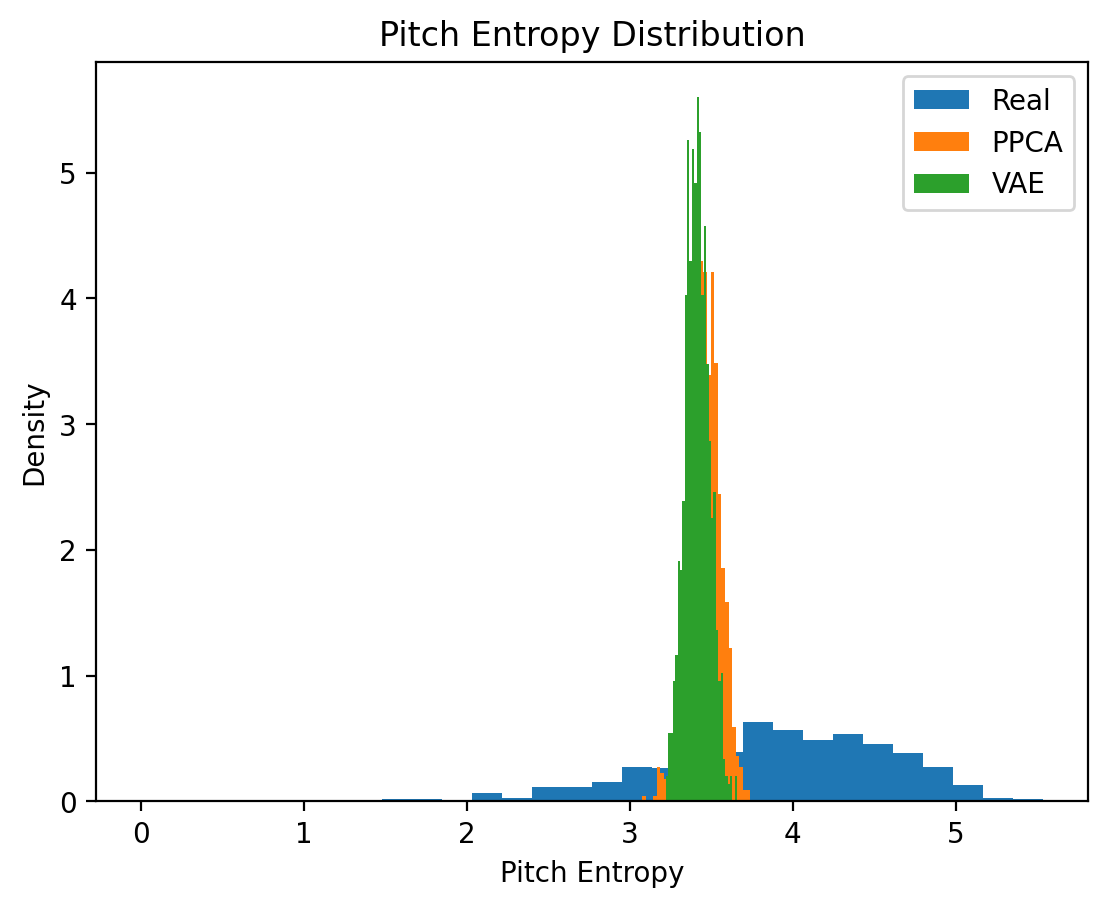

In [ ]:
plt.hist(pitch_entropies_original, bins=30, density=True, label= "Real")
plt.hist(pitch_entropies_ppca, bins=30, density=True, label="PPCA")
plt.hist(pitch_entropies_vae, bins= 30, density= True, label = "VAE")
plt.xlabel("Pitch Entropy")
plt.ylabel("Density")
plt.title("Pitch Entropy Distribution")
plt.legend()
plt.show()


### Pitch range

In [ ]:
def pitch_range(music):
    pitches = []
    for track in music.tracks:
        for note in track.notes:
            pitches.append(note.pitch)
    if len(pitches) == 0:
        return 0

    return max(pitches) - min(pitches)

In [ ]:
pitch_ranges_original = [
    pitch_range(music)
    for music in original_nes_musics
]

pitch_ranges_ppca = [
    pitch_range(music)
    for music in ppca_nes_musics
]

pitch_ranges_vae = [
    pitch_range(music)
    for music in vae_nes_musics
]


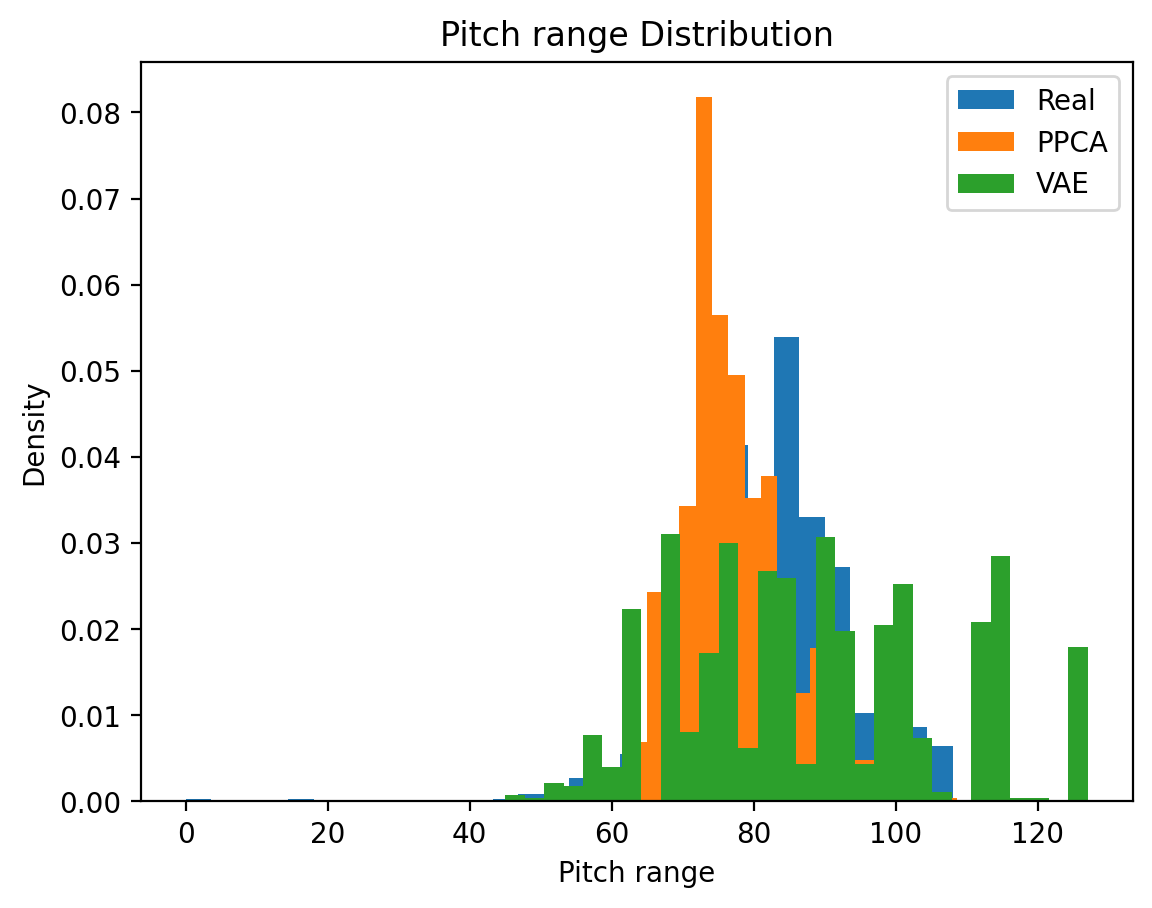

In [ ]:
plt.hist(pitch_ranges_original, bins=30, density=True, label= "Real")
plt.hist(pitch_ranges_ppca, bins=30, density=True, label="PPCA")
plt.hist(pitch_ranges_vae, bins= 30, density= True, label = "VAE")
plt.xlabel("Pitch range")
plt.ylabel("Density")
plt.title("Pitch range Distribution")
plt.legend()
plt.show()

### Rhythm entropy

In [ ]:
def rhythm_entropy(music):
    onsets = []
    for track in music.tracks:
        for note in track.notes:
            onsets.append(note.time)
    if len(onsets) < 2:
        return np.nan

    onsets = np.sort(onsets)
    intervals = np.diff(onsets)
    intervals = intervals[intervals > 0]

    if len(intervals) == 0:
        return np.nan

    _, counts = np.unique(intervals, return_counts=True)
    probs = counts / counts.sum()

    entropy = -np.sum(probs * np.log2(probs))
    return entropy

In [ ]:
rhythm_entropy_original = [
    rhythm_entropy(music)
    for music in original_nes_musics
]

rhythm_entropy_ppca = [
    rhythm_entropy(music)
    for music in ppca_nes_musics
]

rhythm_entropy_vae = [
    rhythm_entropy(music)
    for music in vae_nes_musics
]

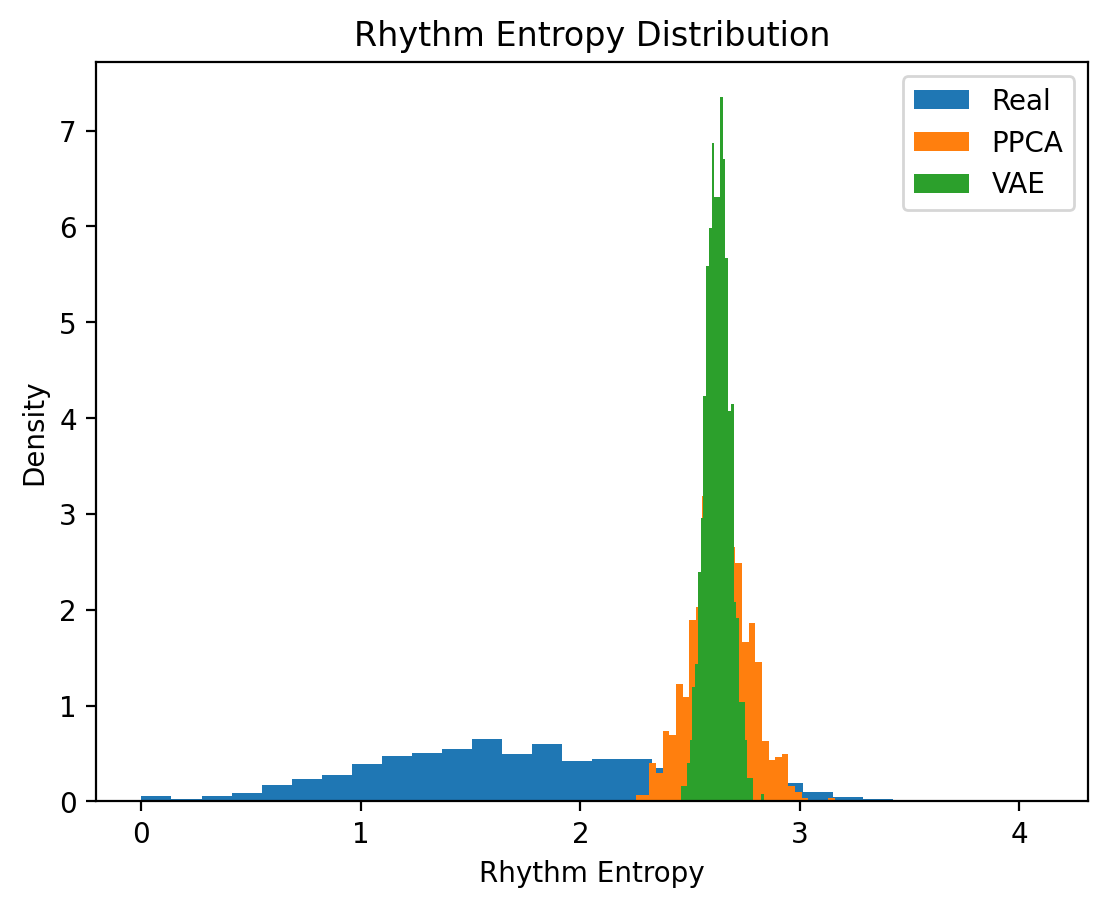

In [ ]:
plt.hist(rhythm_entropy_original, bins=30, density=True, label= "Real")
plt.hist(rhythm_entropy_ppca, bins=30, density=True, label="PPCA")
plt.hist(rhythm_entropy_vae, bins= 30, density= True, label = "VAE")
plt.xlabel("Rhythm Entropy")
plt.ylabel("Density")
plt.title("Rhythm Entropy Distribution")
plt.legend()
plt.show()